<a href="https://colab.research.google.com/github/KangDongJun-ux/MOBILITY/blob/main/%EB%94%A5%EB%9F%AC%EB%8B%9D_%EA%B0%95%EC%9D%98_(%ED%9A%8C%EA%B7%80%2C_%EB%A1%9C%EC%A7%80%EC%8A%A4%ED%8B%B1)_%ED%8C%8C%EC%9D%B4%ED%86%A0%EC%B9%98%EC%8B%9D_%EC%BD%94%EB%94%A9%ED%8C%A8%ED%84%B4_(2)%2C_%EB%A1%9C%EC%A7%80%EC%8A%A4%ED%8B%B1_%EB%AA%A8%ED%98%95_%EC%97%B0%EC%8A%B5_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  (회귀, 로지스틱) -- 파이토치식 코딩패턴 (2), 로지스틱 모형

In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
plt.rcParams['figure.figsize'] = (4.5, 3.0)

## 3. 파이토치식 코딩패턴(2)

**데이터**

In [8]:
torch.manual_seed(43052)
x,_ = torch.randn(100).sort()
eps = torch.randn(100)*0.5
X = torch.stack([torch.ones(100),x],axis=1)
W = torch.tensor([[2.5],[4.0]])
y = X@W + eps.reshape(100,1)
x = X[:,[1]]

### A. bias의 사용

** net에서 bias를 사용**

In [10]:
# step1을 위한 사전 준비
net = torch.nn.Linear(
    in_features = 1,
    out_features=1,
    bias = True
) # net(x) = x@net.weight.T + net.bias
net.bias.data = torch.tensor([-5.0])
net.weight.data = torch.tensor([[10.0]])
# step2를 위한 사전 준비
loss_fn = torch.nn.MSELoss()
# setp4를 위한 사전 준비
optimizr = torch.optim.SGD(net.parameters(), lr =0.1)
for epoc in range(30):
  # step 1: yhat
  yhat = net(x)
  # step 2: loss
  loss = loss_fn(yhat,y)
  # step 3: 미분
  loss.backward()
  # step 4: update
  optimizr.step()
  optimizr.zero_grad()

In [11]:
net.bias.data, net.weight.data

(tensor([2.4290]), tensor([[4.0144]]))

## B. 잘못된(?) 코드

In [13]:
# step1을 위한 사전준비
net = torch.nn.Linear(
    in_features=2,
    out_features=1,
    # bias: default = True
)
net.weight.data = torch.tensor([[-5.0,  10.0]])
# step2를 위한 사전준비
loss_fn = torch.nn.MSELoss()
# step4를 위한 사전준비
optimizr = torch.optim.SGD(net.parameters(),lr=0.1)
for epoc in range(30):
    # step1: yhat
    yhat = net(X)
    # step2: loss
    loss = loss_fn(yhat,y)
    # step3: 미분
    loss.backward()
    # step4: update
    optimizr.step()
    optimizr.zero_grad()

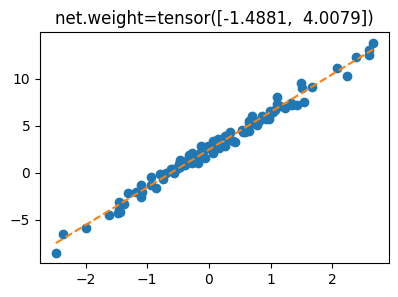

In [14]:
plt.plot(x,y,'o')
plt.plot(x, yhat.data,'--')
plt.title(f'net.weight={net.weight.data.reshape(-1)}');

`-` 나쁘지 않은 이유는?

In [15]:
# step1을 위한 사전준비
net = torch.nn.Linear(
    in_features=2,
    out_features=1,
)
yhat = net(X) = X@net.weight.T + net.bias

SyntaxError: cannot assign to function call (<ipython-input-15-8d013e5b9d88>, line 6)

In [17]:
net.weight

Parameter containing:
tensor([[-1.4881,  4.0079]], requires_grad=True)

In [18]:
net.bias

Parameter containing:
tensor([3.9329], requires_grad=True)

## 4. 로지스틱 모형

### A.
$\hat{\bf y} =??$

`-` ${\bf X}$를 가지고 ${\bf y}$를 맞추는 아래와 같은 문제

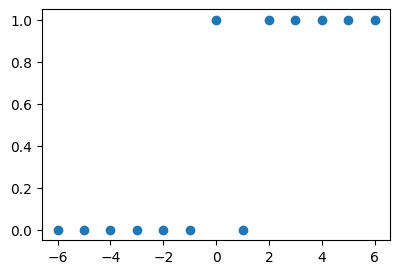

In [19]:
x = torch.tensor([-6,-5,-4,-3,-2,-1, 0, 1, 2, 3, 4, 5, 6.0]).reshape(-1,1)
y = torch.tensor([ 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1]).reshape(-1,1)
plt.plot(x,y,'o')

`-` 아래와 같이 모형화 하면?

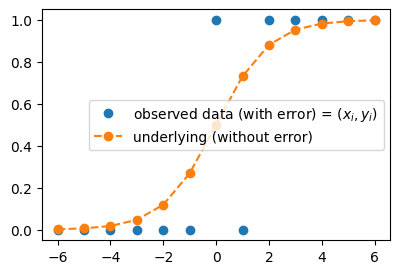

In [20]:
plt.plot(x,y,'o', label=r"observed data (with error) = $(x_i,y_i)$")
plt.plot(x,torch.exp(x)/(1+torch.exp(x)),'o--', label = "underlying (without error)")
plt.legend()

# 데이터를 따라가면 안되고 error-free한 structure을 만들어야 한다.

### B.
$\hat{\bf y} = \frac{\exp(\text{linr}({\bf X}))}{1+\exp(\text{linr}({\bf X}))}$

- $x$가 증가할수록 $y$가 0이 된다면?
- 0근처에서 변화가 일어나지 않고 2근처에서 변화가 일어난다면?
- 변화가 좀 더 급하게 (혹은 완만하게 일어난다면?)

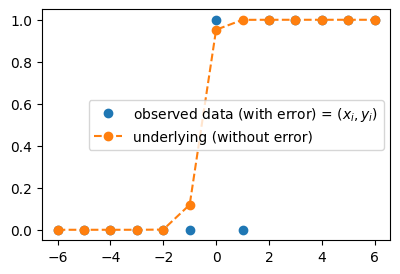

In [21]:
plt.plot(x,y,'o', label=r"observed data (with error) = $(x_i,y_i)$")
plt.plot(x,torch.exp(5*x+3)/(1+torch.exp(5*x+3)),'o--', label = "underlying (without error)")
plt.legend()

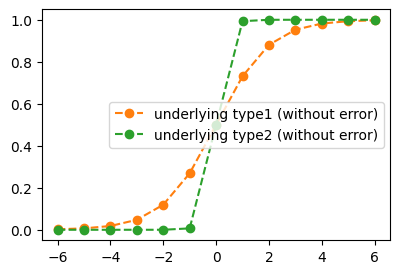

In [24]:
# plt.plot(x,y,'o', label=r"observed data (with error) = $(x_i,y_i)$")
plt.plot(x,torch.exp(x)/(1+torch.exp(x)),'o--', label = "underlying type1 (without error)", color="C1")
plt.plot(x,torch.exp(5*x)/(1+torch.exp(5*x)),'o--', label = "underlying type2 (without error)", color="C2")
plt.legend()

**회귀 vs 로지스틱**

- ${\bf X} \to {\bf y}$ 에 대한 패턴이 $\text{linr}({\bf X}) \approx {\bf y}$ 이라면 회귀!
- ${\bf X} \to {\bf y}$ 에 대한 패턴이 $\frac{\exp(\text{linr}({\bf X}))}{1+\exp(\text{linr}({\bf X}))} \approx {\bf y}$ 이라면 로지스틱!
:::

### C. 로지스틱 모형

`-` $x$가 커질수록 (혹은 작아질수록) $y=1$이 잘나오는 모형은 아래와 같이 설계할 수 있음
\<— 외우세요!!!

-   $y_i \sim {\cal B}(\pi_i),\quad$ where
$\pi_i = \frac{\exp(w_0+w_1x_i)}{1+\exp(w_0+w_1x_i)} = \frac{1}{1+\exp(-w_0-w_1x_i)}$

-   $\hat{y}_i= \frac{\exp(\hat{w}_0+\hat{w}_1x_i)}{1+\exp(\hat{w}_0+\hat{w}_1x_i)}=\frac{1}{1+\exp(-\hat{w}_0-\hat{w}_1x_i)}$

`-` 회귀모형과 로지스틱 모형의 비교

- 회귀모형: $y_i \sim {\cal N}(w_0+w_1x_i, \sigma^2)$^[원래는 이렇게 썼었지.. $y_i = w_0 + w_1x_i + \epsilon_i \quad \epsilon_i \sim {\cal N}(0,\sigma^2)$]
- 로지스틱: $y_i \sim {\cal B}\big(\frac{\exp(w_0+w_1x_i)}{1+\exp(w_0+w_1x_i)}\big)$

`-` 우리가 예측하고 싶은것

- 회귀모형: 정규분포의 평균을 예측하고 싶음. 즉 $w_0+w_1x_i$를 예측하고 싶음. 예측값으로는 $\hat{w}_0 + \hat{w}_1x_i$를 사용!
- 로지스틱: 베르누이의 평균을 예측하고 싶음. 즉 $\frac{\exp(w_0+w_1x_i)}{1+\exp(w_0+w_1x_i)}$를 예측하고 싶음. 예측값으로는 $\frac{\exp(\hat{w}_0+\hat{w}_1x_i)}{1+\exp(\hat{w}_0+\hat{w}_1x_i)}$를 사용!